# Kalman Smoother on log price for exogenous Fundamental Value Signal

Calm (2018–2019):  SNR=5.522  σ_η=0.008178  σ_ε=0.001481
Stressed (2008–2009):  SNR=3.201  σ_η=0.048739  σ_ε=0.015228


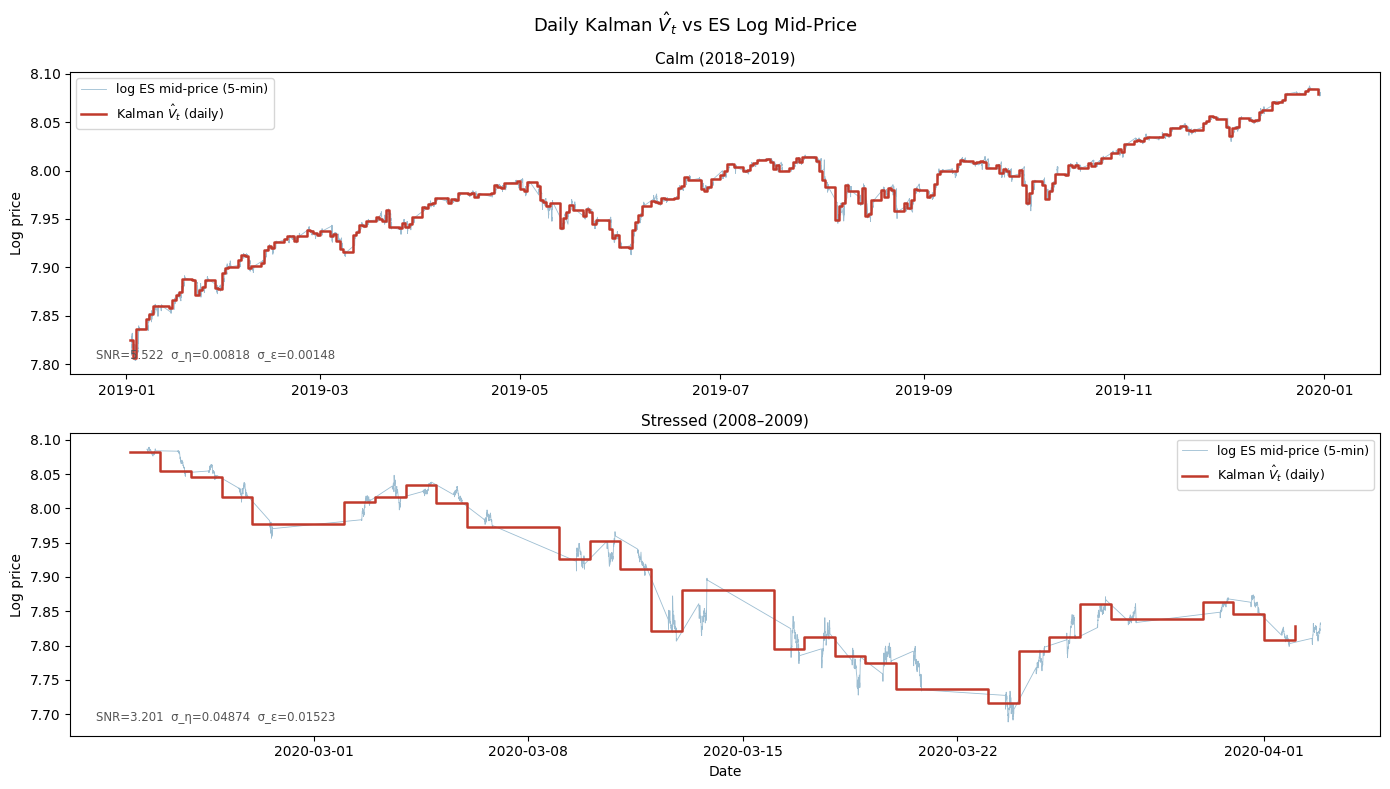

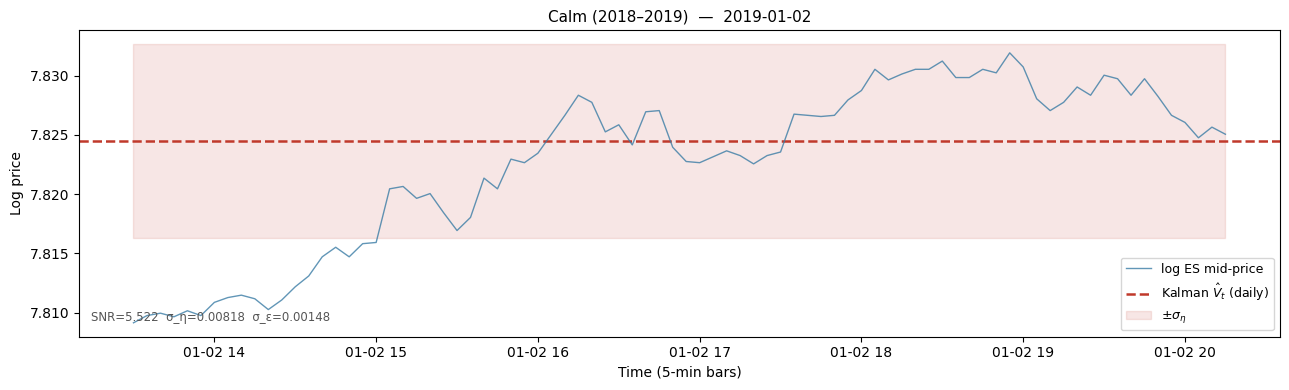

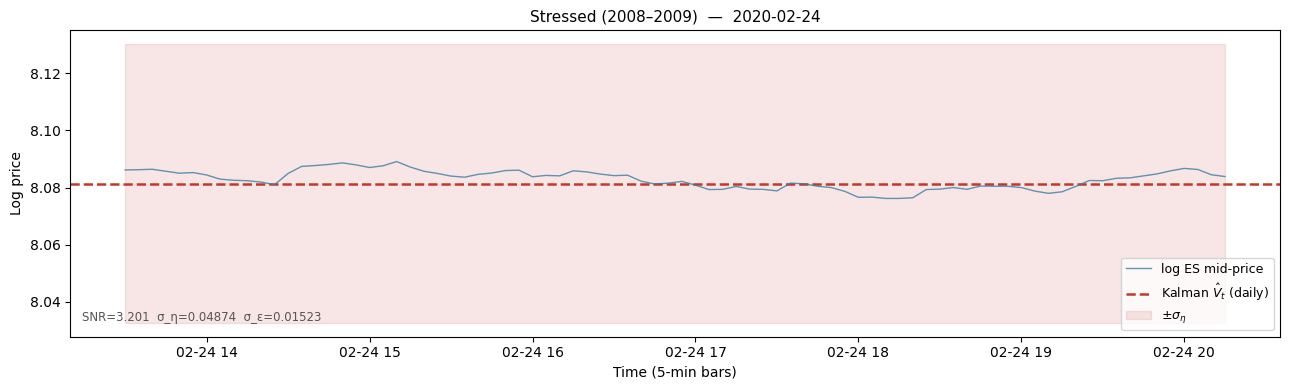

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


def kalman_smooth(log_prices, snr, sigma_eta=None):
    n = len(log_prices)
    if sigma_eta is None:
        sigma_eta = np.std(np.diff(log_prices))
    sigma_eps = sigma_eta / snr
    v_filt, P = np.empty(n), np.empty(n)
    v_pred, p_pred = log_prices[0], sigma_eta**2
    for t in range(n):
        S = p_pred + sigma_eps**2
        K = p_pred / S
        v_filt[t] = v_pred + K * (log_prices[t] - v_pred)
        P[t] = (1 - K) * p_pred
        v_pred, p_pred = v_filt[t], P[t] + sigma_eta**2
    v_smooth = v_filt.copy()
    for t in range(n - 2, -1, -1):
        G = P[t] / (P[t] + sigma_eta**2)
        v_smooth[t] += G * (v_smooth[t + 1] - v_filt[t])
    return v_smooth, sigma_eta, sigma_eps


def estimate_snr(log_prices):
    sigma_eta = np.std(np.diff(log_prices))
    def neg_ll(log_snr):
        sigma_eps = sigma_eta / np.exp(log_snr)
        v_pred, p_pred, ll = log_prices[0], sigma_eta**2, 0.0
        for obs in log_prices:
            S = p_pred + sigma_eps**2
            ll -= 0.5 * (np.log(S) + (obs - v_pred)**2 / S)
            K = p_pred / S
            v_pred = v_pred + K * (obs - v_pred)
            p_pred = (1 - K) * p_pred + sigma_eta**2
        return -ll
    return float(np.exp(minimize_scalar(neg_ll, bounds=(-6, 4), method="bounded").x))


calm     = pd.read_csv("data/processed/ES_front_calm_5m.csv",     parse_dates=["ts"]).sort_values("ts")
stressed = pd.read_csv("data/processed/ES_front_stressed_5m.csv", parse_dates=["ts"]).sort_values("ts")

results = {}
for label, df in [("Calm (2018–2019)", calm), ("Stressed (2008–2009)", stressed)]:
    # ── Daily close series ────────────────────────────────────────────
    daily = (df.set_index("ts")["close"]
               .resample("1B").last()
               .dropna()
               .reset_index())
    daily.columns = ["date", "close"]
    log_daily = np.log(daily["close"].values)

    snr = estimate_snr(log_daily)
    log_v_daily, sigma_eta, sigma_eps = kalman_smooth(log_daily, snr)
    print(f"{label}:  SNR={snr:.3f}  σ_η={sigma_eta:.6f}  σ_ε={sigma_eps:.6f}")

    # ── Forward-fill to 5-min bars ────────────────────────────────────
    daily["V_smooth"] = np.exp(log_v_daily)
    daily["date_only"] = pd.to_datetime(daily["date"]).dt.date
    df["date_only"]   = pd.to_datetime(df["ts"]).dt.date
    df5 = df.merge(daily[["date_only", "V_smooth"]], on="date_only", how="left")

    results[label] = dict(
        df=df, df5=df5, daily=daily,
        log_p=np.log(df["close"].values),
        log_v_daily=log_v_daily,
        log_v_5m=np.log(df5["V_smooth"].values),
        sigma_eta=sigma_eta, sigma_eps=sigma_eps, snr=snr
    )
    out_label = label.split()[0].lower()
    df5[["ts", "V_smooth"]].to_csv(f"data/fv_{out_label}.csv", index=False)


# ── Full-period overview ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, (label, res) in zip(axes, results.items()):
    t5  = res["df"]["ts"].values
    td  = res["daily"]["date"].values
    ax.plot(t5, res["log_p"],    color="#3a7ca5", lw=0.6, alpha=0.5, label="log ES mid-price (5-min)")
    ax.step(td, res["log_v_daily"], color="#c0392b", lw=1.8, where="post", label="Kalman $\\hat{V}_t$ (daily)")
    ax.set_title(label, fontsize=11)
    ax.set_ylabel("Log price")
    ax.legend(fontsize=9)
    ax.annotate(f"SNR={res['snr']:.3f}  σ_η={res['sigma_eta']:.5f}  σ_ε={res['sigma_eps']:.5f}",
                xy=(0.02, 0.05), xycoords="axes fraction", fontsize=8.5, color="#555")
axes[-1].set_xlabel("Date")
fig.suptitle("Daily Kalman $\\hat{V}_t$ vs ES Log Mid-Price", fontsize=13)
plt.tight_layout()
plt.show()


# ── Single-day zoom (5-min bars, V_t as flat daily step) ──────────────
for label, res in results.items():
    df5 = res["df5"].copy()
    df5["date_only"] = pd.to_datetime(df5["ts"]).dt.date
    first_day = df5["date_only"].iloc[0]
    mask = df5["date_only"] == first_day
    t   = pd.to_datetime(df5.loc[mask, "ts"]).values
    lp  = res["log_p"][mask.values]
    lv  = res["log_v_5m"][mask.values]

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(t, lp, color="#3a7ca5", lw=1.0, alpha=0.8, label="log ES mid-price", zorder=3)
    ax.axhline(lv[0], color="#c0392b", lw=1.8, ls="--", label="Kalman $\\hat{V}_t$ (daily)", zorder=2)
    ax.fill_between(t, lv[0] - res["sigma_eta"], lv[0] + res["sigma_eta"],
                    color="#c0392b", alpha=0.12, zorder=1, label="$\\pm\\sigma_\\eta$")
    ax.set_title(f"{label}  —  {first_day}", fontsize=11)
    ax.set_ylabel("Log price")
    ax.set_xlabel("Time (5-min bars)")
    ax.legend(fontsize=9)
    ax.annotate(f"SNR={res['snr']:.3f}  σ_η={res['sigma_eta']:.5f}  σ_ε={res['sigma_eps']:.5f}",
                xy=(0.01, 0.05), xycoords="axes fraction", fontsize=8.5, color="#555")
    plt.tight_layout()
    plt.show()